In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn plotly -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, load_digits, fetch_olivetti_faces
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


Covariance Matrix:
[[2.7186379  1.84079041]
 [1.84079041 1.87427921]]

Eigenvalues: [4.18504129 0.40787583]
Eigenvectors:
[[ 0.78215821 -0.62307987]
 [ 0.62307987  0.78215821]]


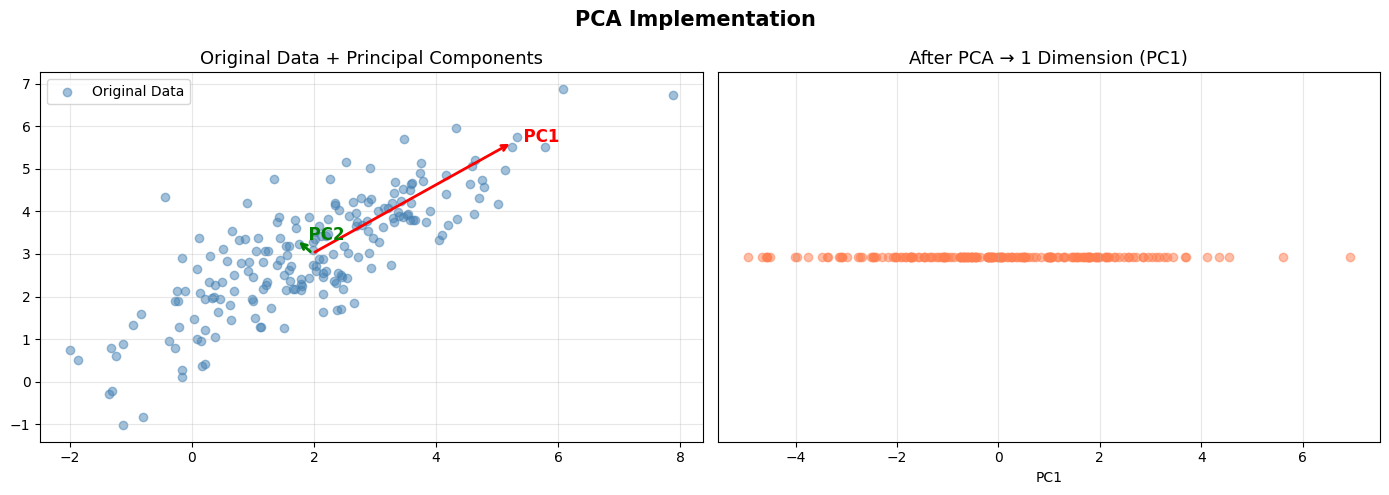

PCA completed!


In [3]:
np.random.seed(42)
mean = [2, 3]
cov = [[3, 2], [2, 2]] 
X = np.random.multivariate_normal(mean, cov, 200)
X_centered = X - np.mean(X, axis=0)
cov_matrix = np.cov(X_centered.T)
print('Covariance Matrix:')
print(cov_matrix)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print(f'\nEigenvalues: {eigenvalues}')
print(f'Eigenvectors:\n{eigenvectors}')
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]
X_pca_manual = X_centered @ eigenvectors[:, :1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X[:, 0], X[:, 1], alpha=0.5, color='steelblue', label='Original Data')
origin = np.mean(X, axis=0)
for i, (val, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    axes[0].annotate('', xy=origin + val*vec, xytext=origin,
                     arrowprops=dict(arrowstyle='->', color=['red','green'][i], lw=2))
    axes[0].text(*(origin + val*vec), f'  PC{i+1}', fontsize=12,
                 color=['red','green'][i], fontweight='bold')
axes[0].set_title('Original Data + Principal Components', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_pca_manual, np.zeros_like(X_pca_manual), alpha=0.5, color='coral')
axes[1].set_title('After PCA → 1 Dimension (PC1)', fontsize=13)
axes[1].set_xlabel('PC1')
axes[1].set_yticks([])
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Implementation', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('PCA completed!')

In [4]:
iris = load_iris()
X_iris = iris.data      
y_iris = iris.target
target_names = iris.target_names

print(f'Original data shape: {X_iris.shape}')  
print(f'Features: {iris.feature_names}')
print(f'Classes: {target_names}')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'\nShape after PCA: {X_pca.shape}')  
print(f'Explained Variance Ratio: {pca.explained_variance_ratio_}')
print(f'Total Variance Explained: {sum(pca.explained_variance_ratio_)*100:.2f}%')

Original data shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

Shape after PCA: (150, 2)
Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Explained: 95.81%


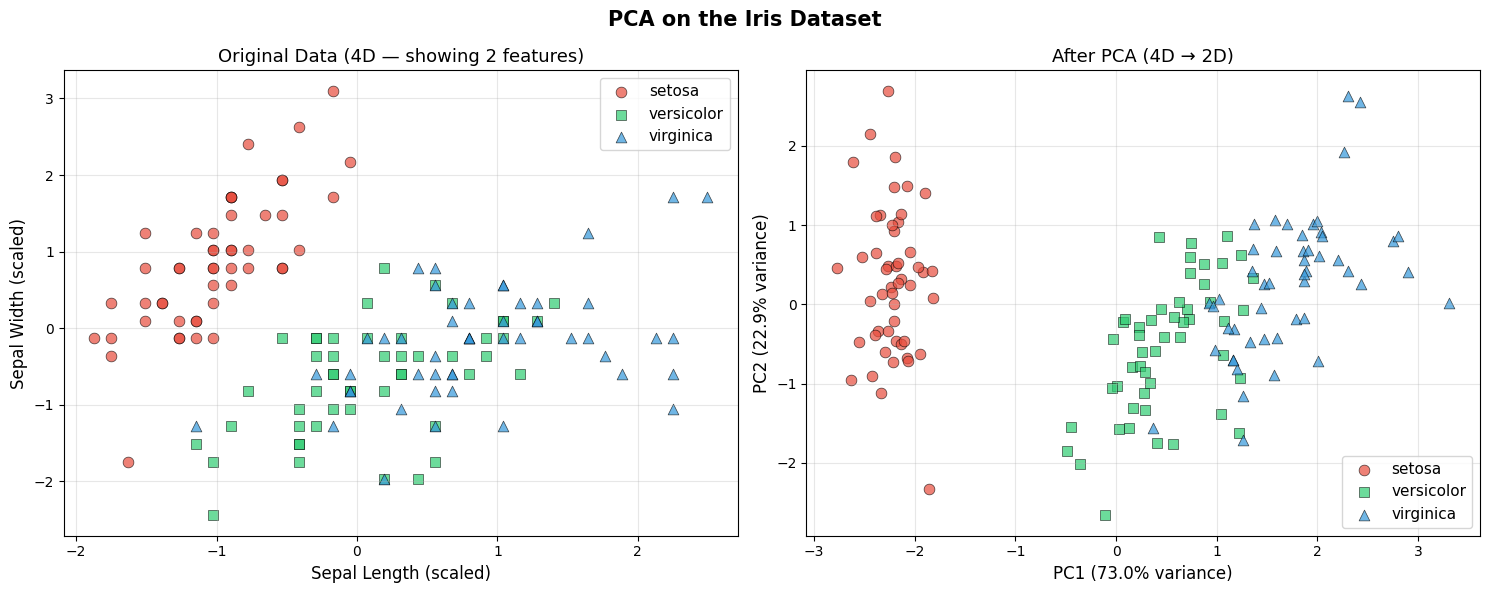

In [5]:
colors  = ['#e74c3c', '#2ecc71', '#3498db']
markers = ['o', 's', '^']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, (name, color, marker) in enumerate(zip(target_names, colors, markers)):
    idx = y_iris == i
    axes[0].scatter(X_scaled[idx, 0], X_scaled[idx, 1], c=color, marker=marker,
                    label=name, alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
axes[0].set_xlabel('Sepal Length (scaled)', fontsize=12)
axes[0].set_ylabel('Sepal Width (scaled)', fontsize=12)
axes[0].set_title('Original Data (4D — showing 2 features)', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# After PCA
for i, (name, color, marker) in enumerate(zip(target_names, colors, markers)):
    idx = y_iris == i
    axes[1].scatter(X_pca[idx, 0], X_pca[idx, 1], c=color, marker=marker,
                    label=name, alpha=0.7, s=60, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
axes[1].set_title('After PCA (4D → 2D)', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA on the Iris Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Digits shape: (1797, 64)


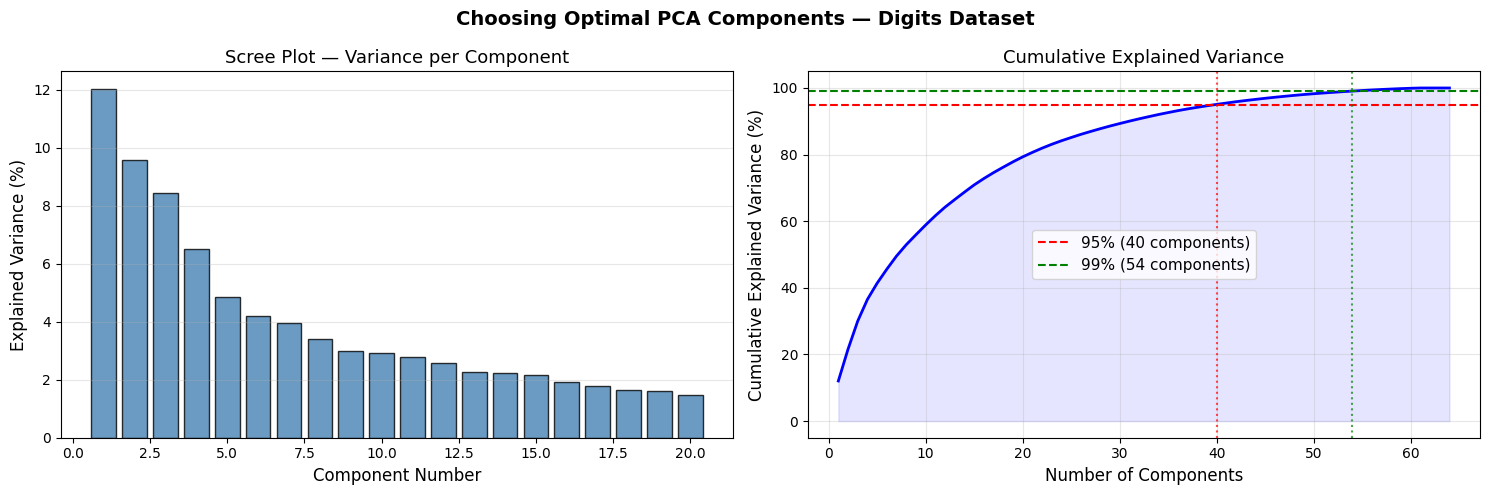


40 components needed to explain 95% of variance
54 components needed to explain 99% of variance
Reduction from 64 features → 40 components (37.5% reduction!)


In [6]:
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f'Digits shape: {X_digits.shape}')  # (1797, 64)

X_digits_scaled = StandardScaler().fit_transform(X_digits)

pca_full = PCA()
pca_full.fit(X_digits_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

n_95 = np.argmax(cumvar >= 0.95) + 1
n_99 = np.argmax(cumvar >= 0.99) + 1

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20] * 100,
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Component Number', fontsize=12)
axes[0].set_ylabel('Explained Variance (%)', fontsize=12)
axes[0].set_title('Scree Plot — Variance per Component', fontsize=13)
axes[0].grid(True, alpha=0.3, axis='y')

# Cumulative Variance Plot
axes[1].plot(range(1, len(cumvar)+1), cumvar * 100, 'b-', linewidth=2)
axes[1].axhline(y=95, color='red',   linestyle='--', label=f'95% ({n_95} components)')
axes[1].axhline(y=99, color='green', linestyle='--', label=f'99% ({n_99} components)')
axes[1].axvline(x=n_95, color='red',   linestyle=':', alpha=0.7)
axes[1].axvline(x=n_99, color='green', linestyle=':', alpha=0.7)
axes[1].fill_between(range(1, len(cumvar)+1), cumvar*100, alpha=0.1, color='blue')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Choosing Optimal PCA Components — Digits Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n{n_95} components needed to explain 95% of variance')
print(f'{n_99} components needed to explain 99% of variance')
print(f'Reduction from 64 features → {n_95} components ({(1-n_95/64)*100:.1f}% reduction!)')

Face data shape: (400, 4096)
Variance explained by 100 components: 93.49%


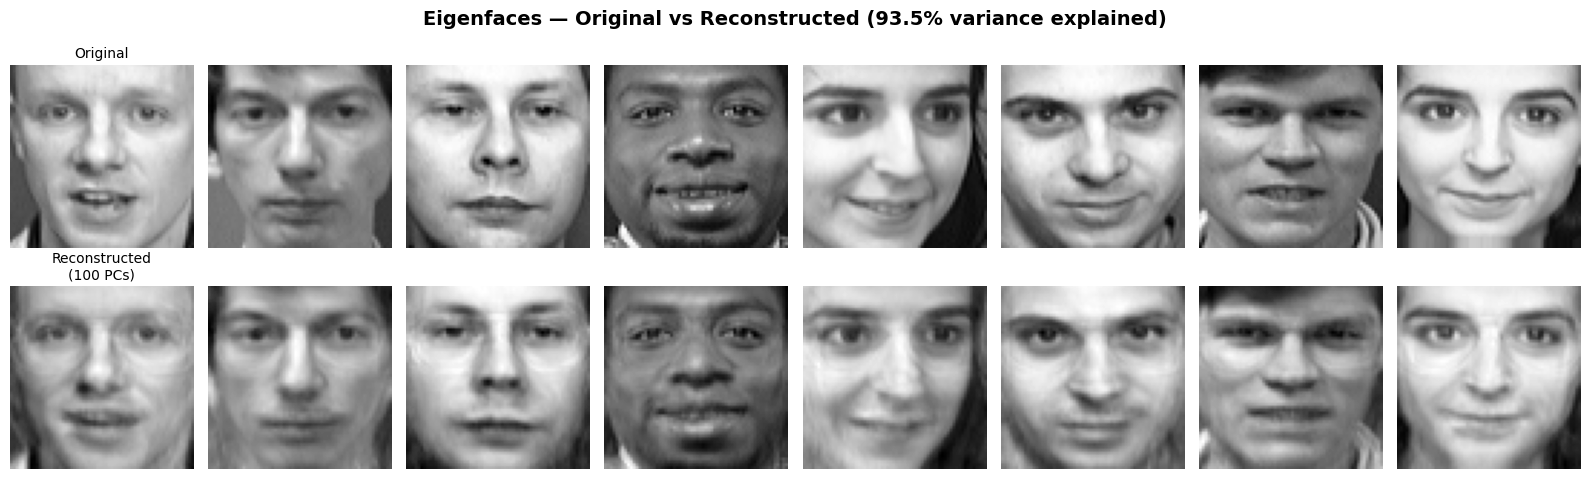

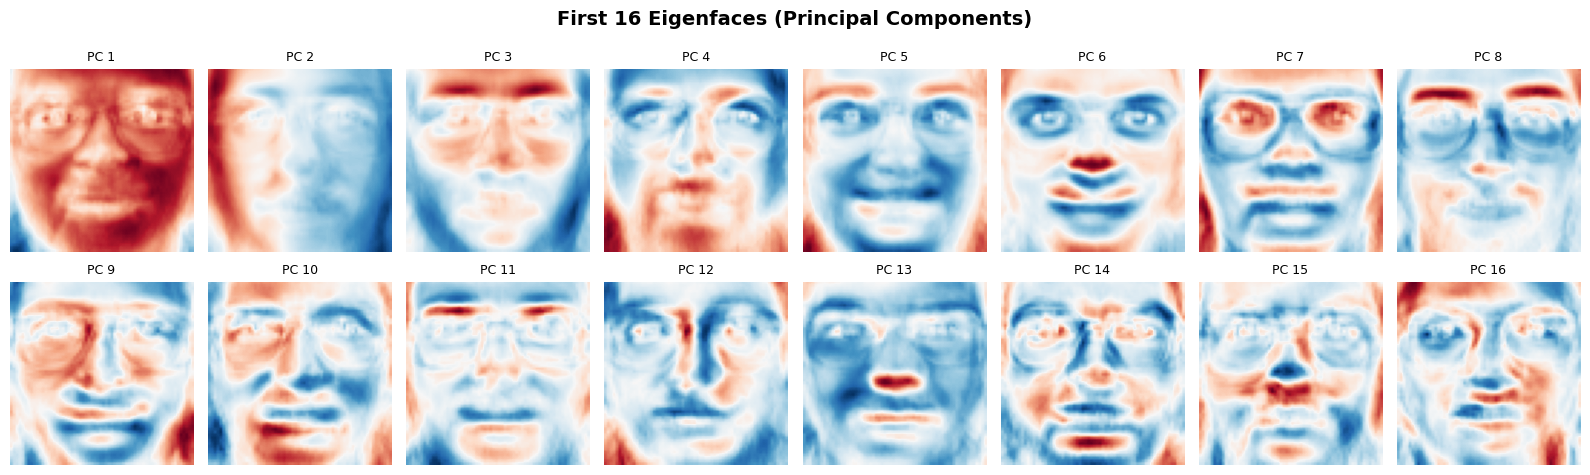

In [7]:
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X_faces = faces.data
print(f'Face data shape: {X_faces.shape}') 

n_components = 100
pca_faces = PCA(n_components=n_components, whiten=True, random_state=42)
X_faces_pca = pca_faces.fit_transform(X_faces)

total_var = sum(pca_faces.explained_variance_ratio_) * 100
print(f'Variance explained by {n_components} components: {total_var:.2f}%')

X_reconstructed = pca_faces.inverse_transform(X_faces_pca)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i in range(8):
    axes[0, i].imshow(X_faces[i].reshape(64, 64), cmap='gray')
    axes[0, i].axis('off')
    if i == 0: axes[0, i].set_title('Original', fontsize=10, pad=5)

    axes[1, i].imshow(X_reconstructed[i].reshape(64, 64), cmap='gray')
    axes[1, i].axis('off')
    if i == 0: axes[1, i].set_title(f'Reconstructed\n({n_components} PCs)', fontsize=10, pad=5)

plt.suptitle(f'Eigenfaces — Original vs Reconstructed ({total_var:.1f}% variance explained)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca_faces.components_[i].reshape(64, 64), cmap='RdBu_r')
    ax.set_title(f'PC {i+1}', fontsize=9)
    ax.axis('off')

plt.suptitle('First 16 Eigenfaces (Principal Components)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

     COMPARISON: WITHOUT PCA vs WITH PCA
  Without PCA | Features: 64  | Accuracy: 97.22%
  With PCA    | Features: 40  | Accuracy: 96.11%
  Feature reduction: 64 → 40 (37.5% smaller)


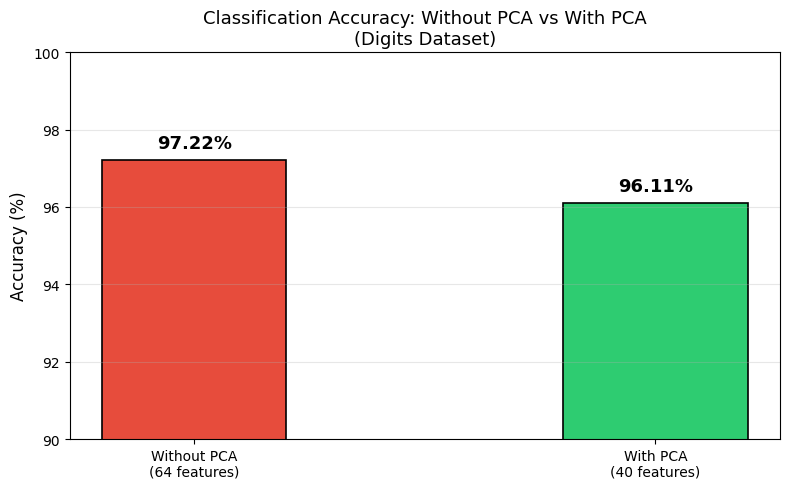

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42)

pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

pipe_no_pca.fit(X_train, y_train)
pipe_pca.fit(X_train, y_train)

acc_no_pca = pipe_no_pca.score(X_test, y_test)
acc_pca    = pipe_pca.score(X_test, y_test)
n_comp     = pipe_pca.named_steps['pca'].n_components_

print('='*55)
print('     COMPARISON: WITHOUT PCA vs WITH PCA')
print('='*55)
print(f'  Without PCA | Features: 64  | Accuracy: {acc_no_pca*100:.2f}%')
print(f'  With PCA    | Features: {n_comp}  | Accuracy: {acc_pca*100:.2f}%')
print('='*55)
print(f'  Feature reduction: 64 → {n_comp} ({(1-n_comp/64)*100:.1f}% smaller)')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Without PCA\n(64 features)', f'With PCA\n({n_comp} features)'],
              [acc_no_pca*100, acc_pca*100],
              color=['#e74c3c', '#2ecc71'], width=0.4,
              edgecolor='black', linewidth=1.2)

for bar, acc in zip(bars, [acc_no_pca, acc_pca]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{acc*100:.2f}%', ha='center', fontsize=13, fontweight='bold')

ax.set_ylim(90, 100)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Classification Accuracy: Without PCA vs With PCA\n(Digits Dataset)', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Total variance explained by 3 PCs: 99.48%


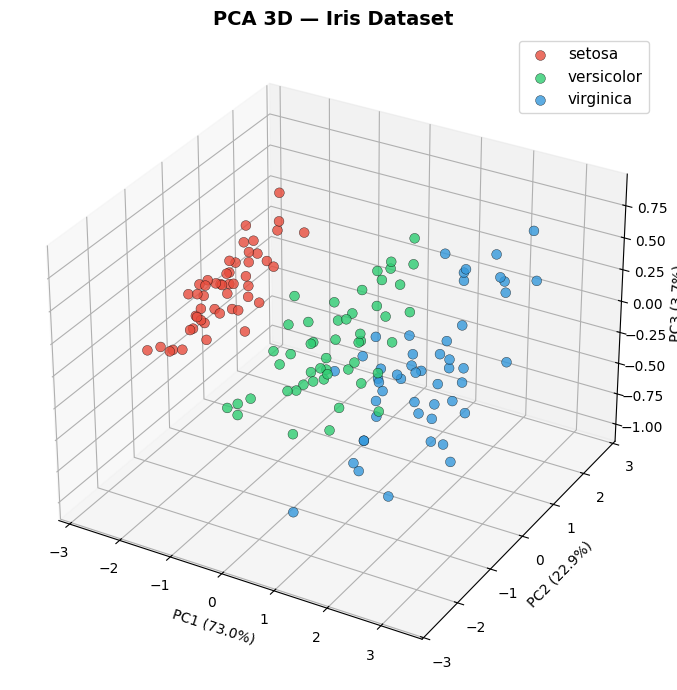

In [9]:
from mpl_toolkits.mplot3d import Axes3D

pca_3d    = PCA(n_components=3)
X_iris_3d = pca_3d.fit_transform(StandardScaler().fit_transform(X_iris))

fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

colors = ['#e74c3c', '#2ecc71', '#3498db']
for i, (name, color) in enumerate(zip(target_names, colors)):
    idx = y_iris == i
    ax.scatter(X_iris_3d[idx, 0], X_iris_3d[idx, 1], X_iris_3d[idx, 2],
               c=color, label=name, s=50, alpha=0.8, edgecolors='black', linewidth=0.3)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=10)
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=10)
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)', fontsize=10)
ax.set_title('PCA 3D — Iris Dataset', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

total = sum(pca_3d.explained_variance_ratio_) * 100
print(f'Total variance explained by 3 PCs: {total:.2f}%')
plt.tight_layout()
plt.show()